# SVD e PCA per l'Analisi di Immagini Mediche

**Progetto — Statistical Methods**

Questo notebook dimostra come le tecniche di **Singular Value Decomposition (SVD)** e
**Principal Component Analysis (PCA)** possano essere utilizzate per comprimere e analizzare
radiografie polmonari in scala di grigi.

**Dataset:** Lung X-Rays Grayscale — 4 classi:
- Corona Virus Disease
- Normal
- Pneumonia
- Tuberculosis

In [24]:
# === IMPORT DEI MODULI DEL PROGETTO ===
from src.config import setup_plot_style
from src.data_loader import (count_images, print_image_counts,
                         load_sample_images, print_sample_properties,
                         load_dataset, load_raw_samples)
from src.svd_engine import apply_svd, print_svd_info
from src.visualization import (plot_exploration, plot_svd_reconstruction,
                           plot_class_comparison, plot_tilt_correction)
from src.analysis import (plot_scree, plot_mse_psnr,print_summary_table)
from src.pca_engine import (run_pca, plot_pca_scatter, plot_eigenfaces)

from src.classification import (prepare_feature_sets, run_classification,
                                plot_confusion_matrix, plot_roc_curves,
                                plot_classification_comparison,
                                plot_hero_tradeoff,
                                plot_knn_vs_lr)

setup_plot_style()

---
## Fase 1 -- Esplorazione dei Dati
Carichiamo le immagini, verifichiamo che siano matrici 2D in scala di grigi e ne studiamo le
caratteristiche statistiche di base.

In [25]:
# === CONTEGGIO IMMAGINI PER CLASSE ===
counts = count_images()
print_image_counts(counts)

CONTEGGIO IMMAGINI NEL DATASET

--- DATASET ---
  Corona Virus Disease          :  122 immagini
  Normal                        :  540 immagini
  Pneumonia                     :  186 immagini
  Tuberculosis                  :  333 immagini


In [26]:
# === CARICAMENTO E VERIFICA CAMPIONI ===
sample_images = load_sample_images()
print_sample_properties(sample_images)


PROPRIETA' DELLE IMMAGINI CAMPIONE

  Classe: Corona Virus Disease
    Shape:  (230, 203)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    255
    Media:  116.07
    Std:    44.54
    2D?     Si [OK]

  Classe: Normal
    Shape:  (1654, 1678)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    255
    Media:  124.91
    Std:    57.82
    2D?     Si [OK]

  Classe: Pneumonia
    Shape:  (1216, 1512)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    255
    Media:  77.16
    Std:    41.98
    2D?     Si [OK]

  Classe: Tuberculosis
    Shape:  (512, 512)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    193
    Media:  126.62
    Std:    39.60
    2D?     Si [OK]


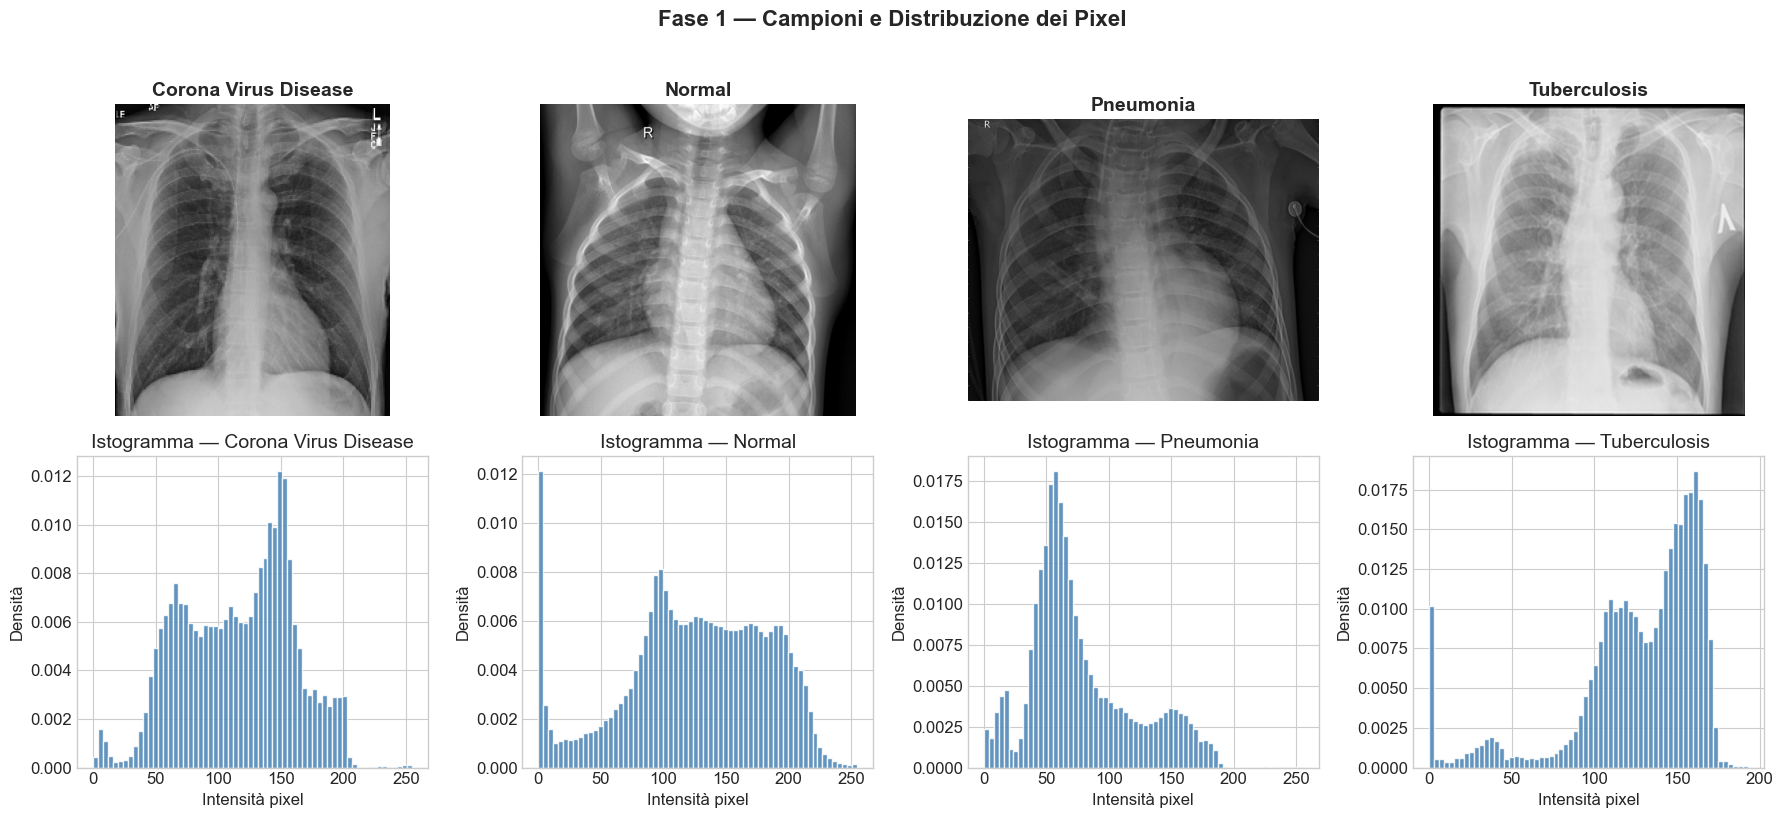

In [27]:
# === VISUALIZZAZIONE CAMPIONI + ISTOGRAMMA DEI PIXEL ===
plot_exploration(sample_images)

---
## Fase 2 -- Pre-elaborazione
Ridimensioniamo tutte le immagini a 256x256, le normalizziamo in [0, 1] e correggiamo
l'eventuale inclinazione (tilt) delle radiografie.

In [28]:
# === CARICAMENTO BATCH PRE-ELABORATO ===
images_by_class, all_images, labels = load_dataset()

  Caricate 116 immagini per 'Corona Virus Disease'  (scartate 6 con tilt > 10°)
  Caricate 120 immagini per 'Normal'  (scartate 1 con tilt > 10°)
  Caricate 120 immagini per 'Pneumonia'  (scartate 1 con tilt > 10°)
  Caricate 120 immagini per 'Tuberculosis'  (scartate 14 con tilt > 10°)

Dataset totale: (476, 256, 256)  --  476 immagini, 256x256 pixel


In [29]:
# === CORREZIONE TILT ===
raw_samples = load_raw_samples()
plot_tilt_correction(raw_samples)

---
## Fase 3 -- SVD: Decomposizione, Ricostruzione e Analisi

La **Singular Value Decomposition** scompone una matrice $A_{m \times n}$ come:

$$A = U \cdot \Sigma \cdot V^T$$

dove:
- $U$ (m x m): vettori singolari sinistri (strutture delle righe)
- $\Sigma$ (diagonale): valori singolari ordinati $\sigma_1 \geq \sigma_2 \geq \dots \geq 0$
- $V^T$ (n x n): vettori singolari destri (strutture delle colonne)

**Approssimazione di rango k:**

$$A_k = \sum_{i=1}^{k} \sigma_i \, \mathbf{u}_i \, \mathbf{v}_i^T$$

Usando solo le prime $k$ componenti si ottiene la migliore approssimazione di rango $k$
(teorema di Eckart-Young).

Tutte le analisi di questa fase operano sulla **SVD di ogni singola immagine** in modo indipendente.

In [30]:
# === DEMO SVD SU UNA SINGOLA IMMAGINE ===
demo_img = images_by_class["Normal"][0]
U, S, Vt = apply_svd(demo_img)
print_svd_info(demo_img, U, S, Vt)

Immagine originale:  256 × 256 = 65,536 valori
Valori singolari:    256 = min(m, n)

Matrice U:   (256, 256)
Vettore S:   (256,)
Matrice Vt:  (256, 256)

Primi 10 valori singolari: [133.23  20.15  16.65  12.27  10.28   7.72   6.12   5.18   4.49   4.39]
Ultimi 5 valori singolari: [0.000904 0.000482 0.000251 0.000165 0.      ]


### 3.1 Demo SVD su una singola immagine
Applichiamo la SVD a un campione della classe *Normal* e osserviamo la struttura
della decomposizione: distribuzione dei valori singolari e decadimento dell'energia.

### 3.2 Ricostruzione con diversi k
Ricostruiamo l'immagine con diversi valori di $k$ e confrontiamo visivamente la qualità.

    k    Compressione         MSE   PSNR (dB)
------------------------------------------------
    1          0.78%    0.018516       17.32
    5          3.91%    0.004147       23.82
   10          7.83%    0.001666       27.78
   20         15.66%    0.000579       32.37
   50         39.14%    0.000098       40.09
  100         78.28%    0.000010       50.00
  200        100.00%    0.000000       71.54


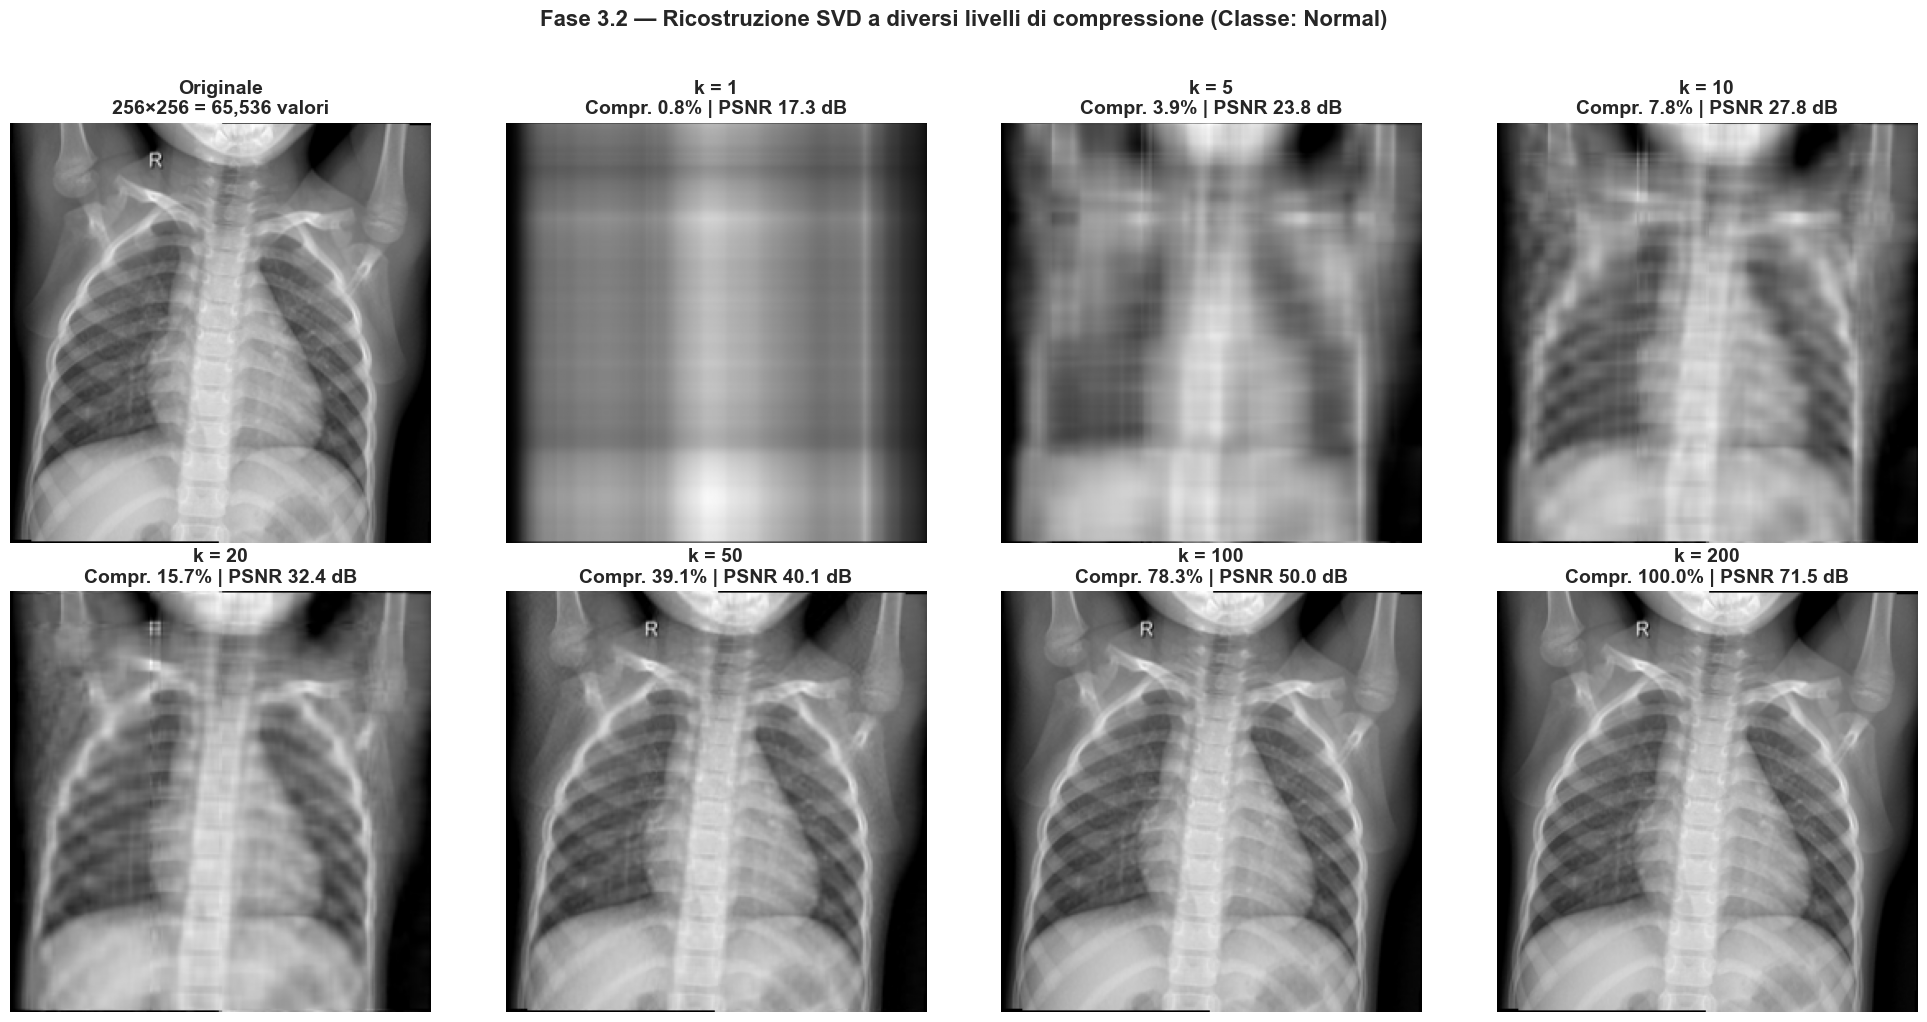

In [31]:
# === RICOSTRUZIONE CON DIVERSI k ===
plot_svd_reconstruction(demo_img, class_name="Normal")

### 3.3 Confronto tra classi
Confronto visivo della qualità di ricostruzione SVD tra le quattro classi diagnostiche.

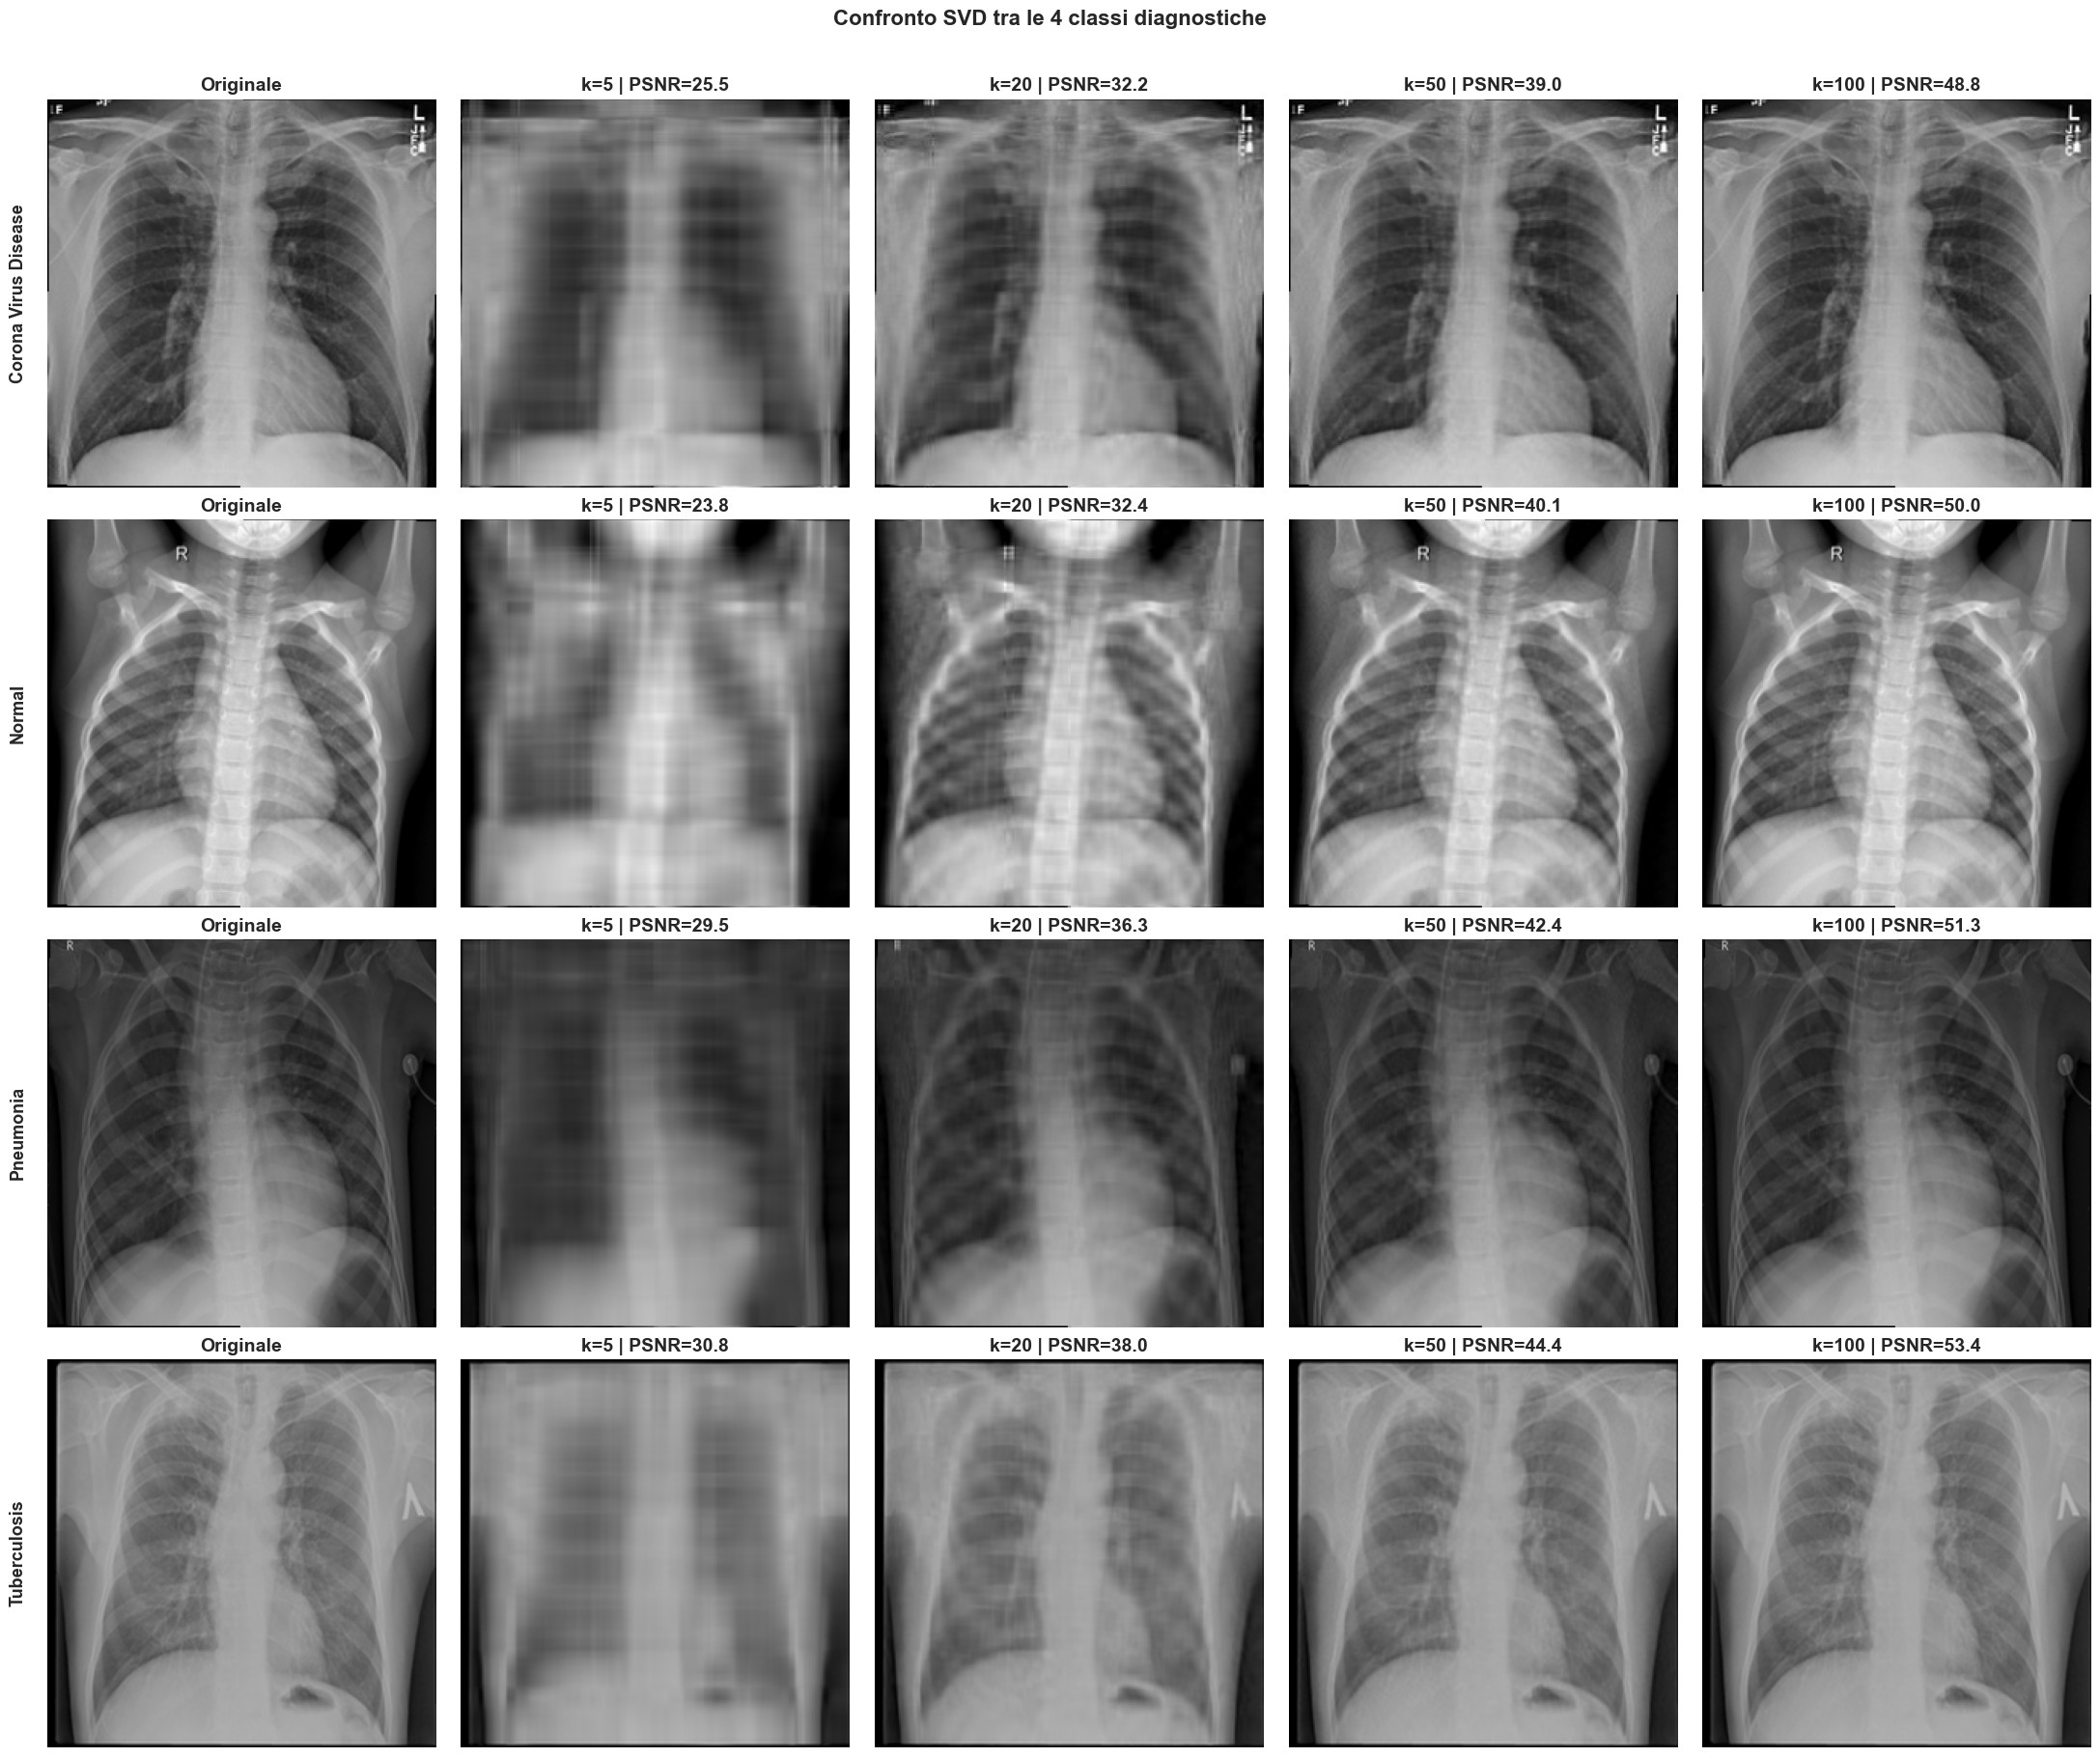

In [32]:
# === CONFRONTO TRA CLASSI ===
plot_class_comparison(images_by_class)

### 3.4 Scree Plot — Varianza Cumulativa dei Valori Singolari
La varianza spiegata dalla $i$-esima componente è proporzionale a $\sigma_i^2$.
La **varianza cumulativa** indica quanti valori singolari servono per catturare una certa
percentuale dell'energia dell'immagine.
Il grafico a destra è in scala logaritmica per espandere visivamente le
differenze tra le classi nella coda dei valori singolari.

> **Nota:** i valori $k(90\%)$, $k(95\%)$, $k(99\%)$ stampati sotto sono medie per classe
> e si riferiscono alla SVD per singola immagine, **non** alla PCA del dataset.

Corona Virus Disease          :  k(90%)=  1   k(95%)=  2   k(99%)=  5  su 256 totali (valori medi)
Normal                        :  k(90%)=  1   k(95%)=  2   k(99%)=  8  su 256 totali (valori medi)
Pneumonia                     :  k(90%)=  1   k(95%)=  2   k(99%)=  7  su 256 totali (valori medi)
Tuberculosis                  :  k(90%)=  1   k(95%)=  2   k(99%)=  5  su 256 totali (valori medi)


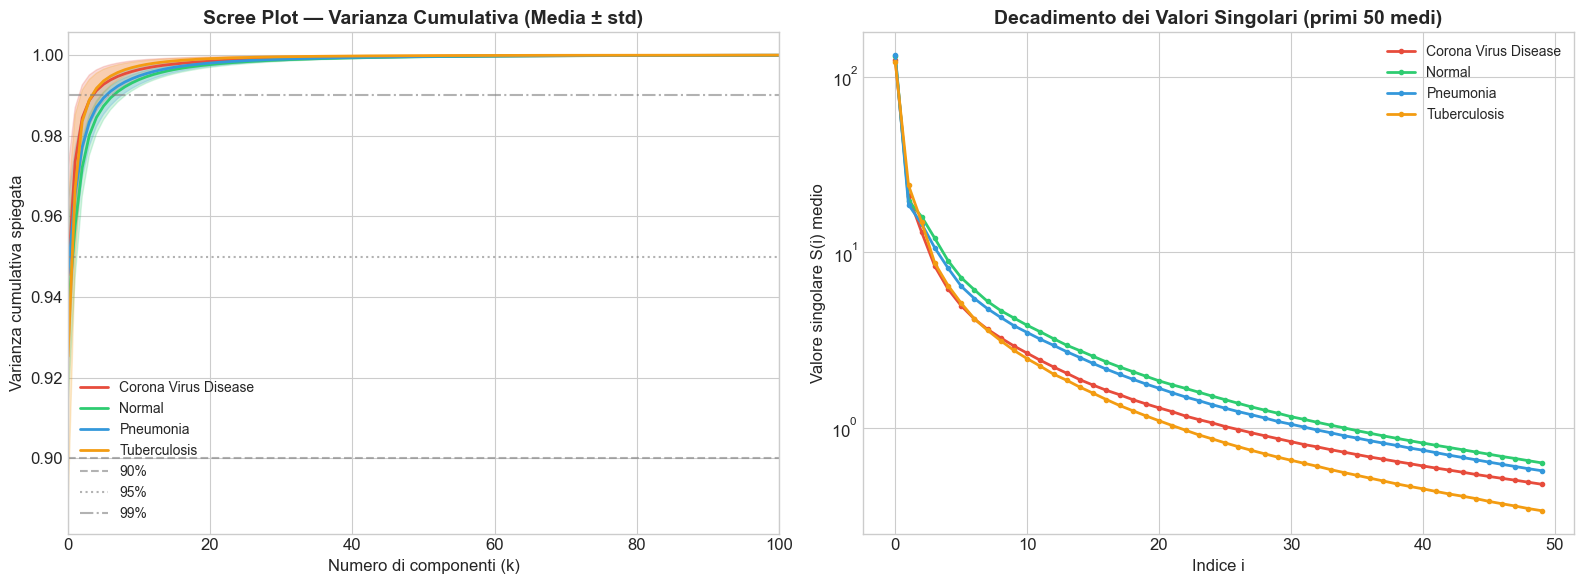

In [33]:
# === SCREE PLOT ===
plot_scree(images_by_class)

### 3.5 Curve MSE e PSNR vs k
Errore di ricostruzione e qualità visiva al variare del numero di componenti $k$ mantenute.

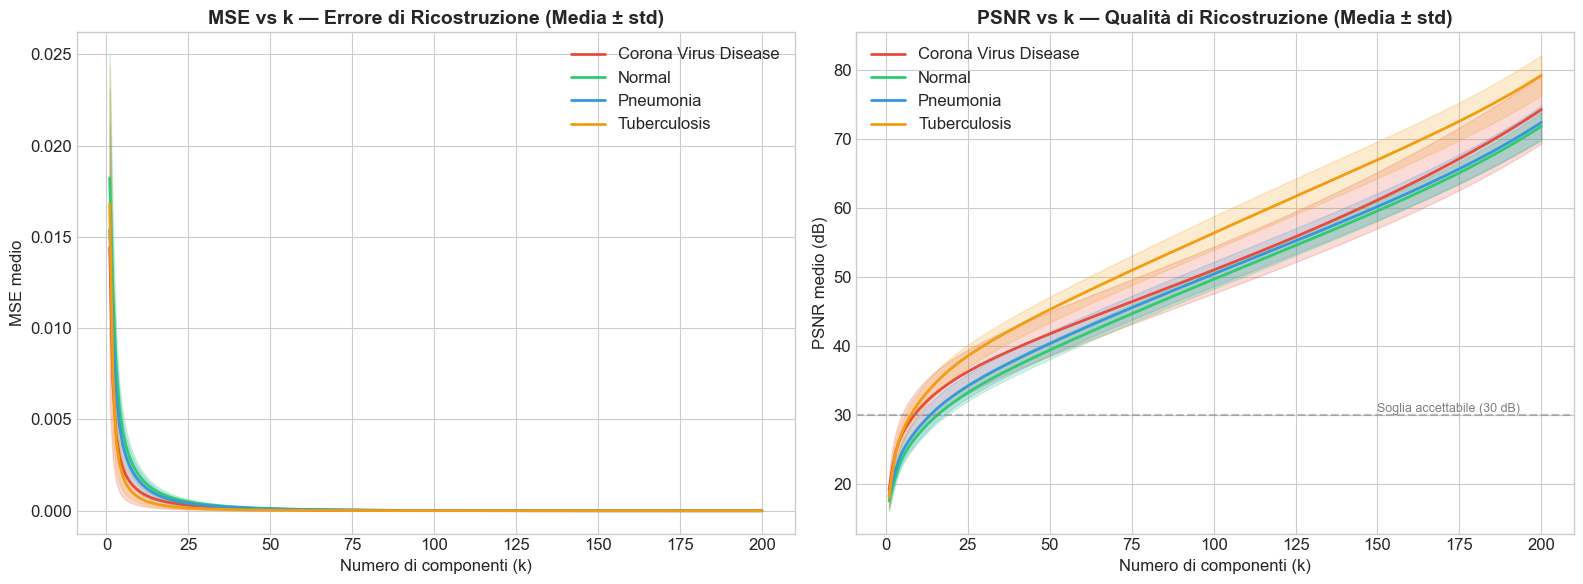

In [34]:
# === CURVA MSE e PSNR vs k ===
plot_mse_psnr(images_by_class)

### 3.6 Tabella Riassuntiva — Trade-off Compressione vs Qualità
Rapporto di compressione, varianza spiegata, MSE e PSNR per valori di $k$ significativi.

> **Nota:** la ricostruzione SVD mostrata qui serve a valutare la **qualità visiva
> della compressione** (PSNR > 30 dB = qualità diagnostica accettabile). In Fase 6
> le immagini ricostruite $A_k$ vengono usate direttamente come input al classificatore
> per testare se la compressione preserva la capacità diagnostica.

In [35]:
# === TABELLA RIASSUNTIVA ===
print_summary_table(demo_img, class_name="Normal")


TABELLA RIASSUNTIVA — TRADE-OFF COMPRESSIONE vs QUALITÀ  (Normal)

    k |  Rapporto Compr. |   Varianza |          MSE |  PSNR (dB)
-----------------------------------------------------------------
    1 |           0.78% |    93.60% |   0.01851605 |      17.32
    5 |           3.91% |    98.56% |   0.00414733 |      23.82
   10 |           7.83% |    99.42% |   0.00166610 |      27.78
   20 |          15.66% |    99.80% |   0.00057890 |      32.37
   50 |          39.14% |    99.97% |   0.00009788 |      40.09
  100 |          78.28% |   100.00% |   0.00000999 |      50.00
  150 |         100.00% |   100.00% |   0.00000105 |      59.77
  200 |         100.00% |   100.00% |   0.00000007 |      71.54
  256 |         100.00% |   100.00% |   0.00000000 |     301.51


---
## Fase 4 -- PCA: Riduzione Dimensionale sul Dataset

A differenza della Fase 3, qui la PCA opera sull'**intero dataset** come unica
matrice $(476 \times 65536)$. La varianza spiegata da ogni componente misura quanta
**variabilità tra immagini diverse** cattura quella direzione — non l'energia di una singola immagine.





In [36]:
# === PCA SUL DATASET ===
pca_model, X_pca = run_pca(all_images)

Matrice dati X: (476, 65536)  (476 campioni, 65536 features)

Varianza spiegata dalle prime 50 componenti: 87.30%


### 4.1 Scatter Plot PCA 2D e Varianza per Componente
La PCA proietta le immagini (vettorizzate) in uno spazio a bassa dimensionalità.
Questo permette di visualizzare la **separabilità** tra le classi diagnostiche.

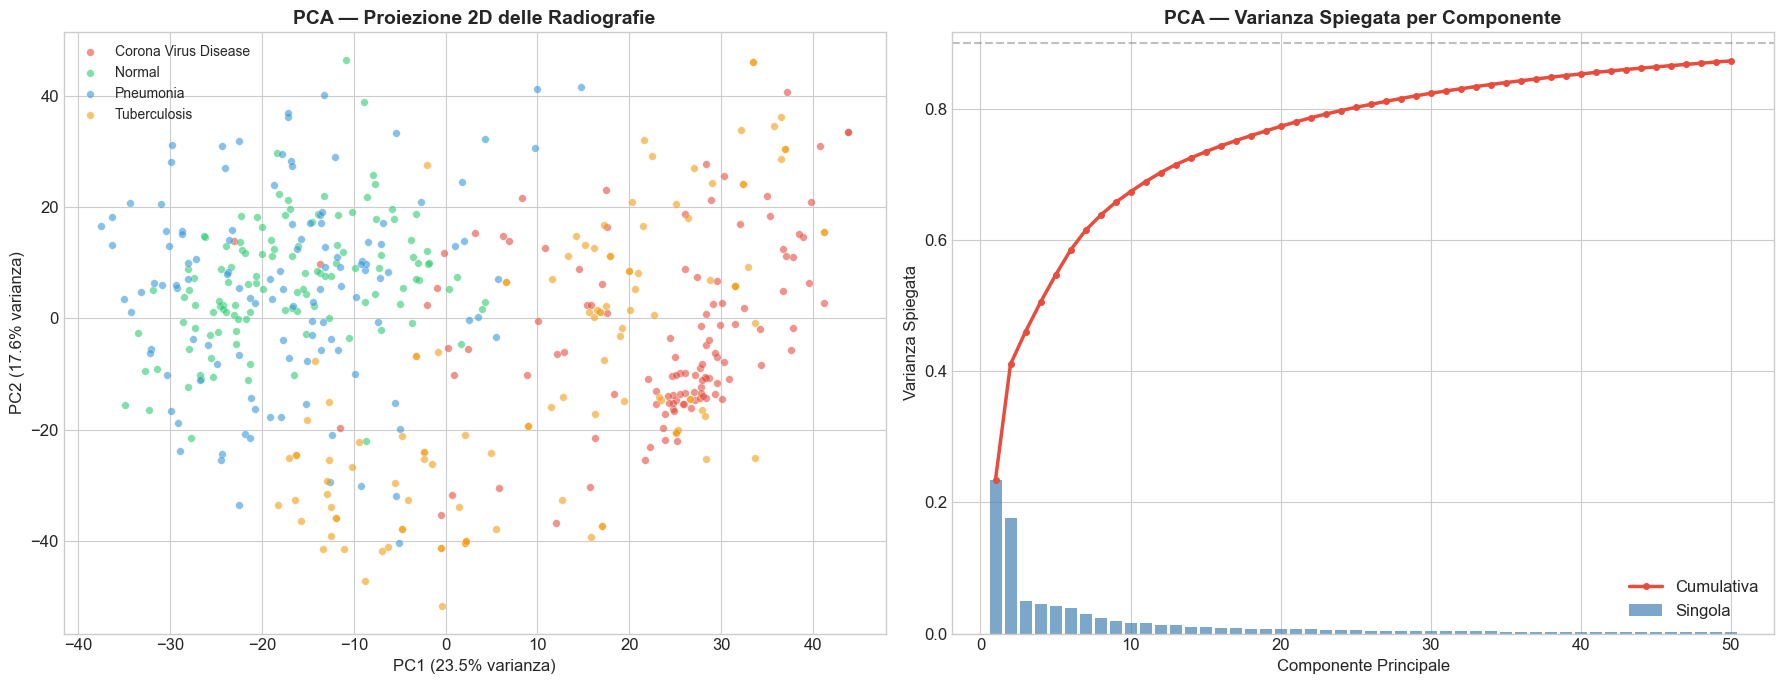

In [37]:
# === SCATTER PLOT PCA 2D ===
plot_pca_scatter(pca_model, X_pca, labels)

### 4.2 Eigen-Xrays — Le Componenti Principali come Immagini
Ogni componente principale è un vettore di 65.536 coefficienti (uno per pixel).
Ridisegnato come matrice 256×256, mostra quali zone dell'immagine variano di più
lungo quella direzione nel dataset. La colormap divergente RdBu indica:
rosso → coefficiente positivo, blu → coefficiente negativo, bianco → irrilevante.

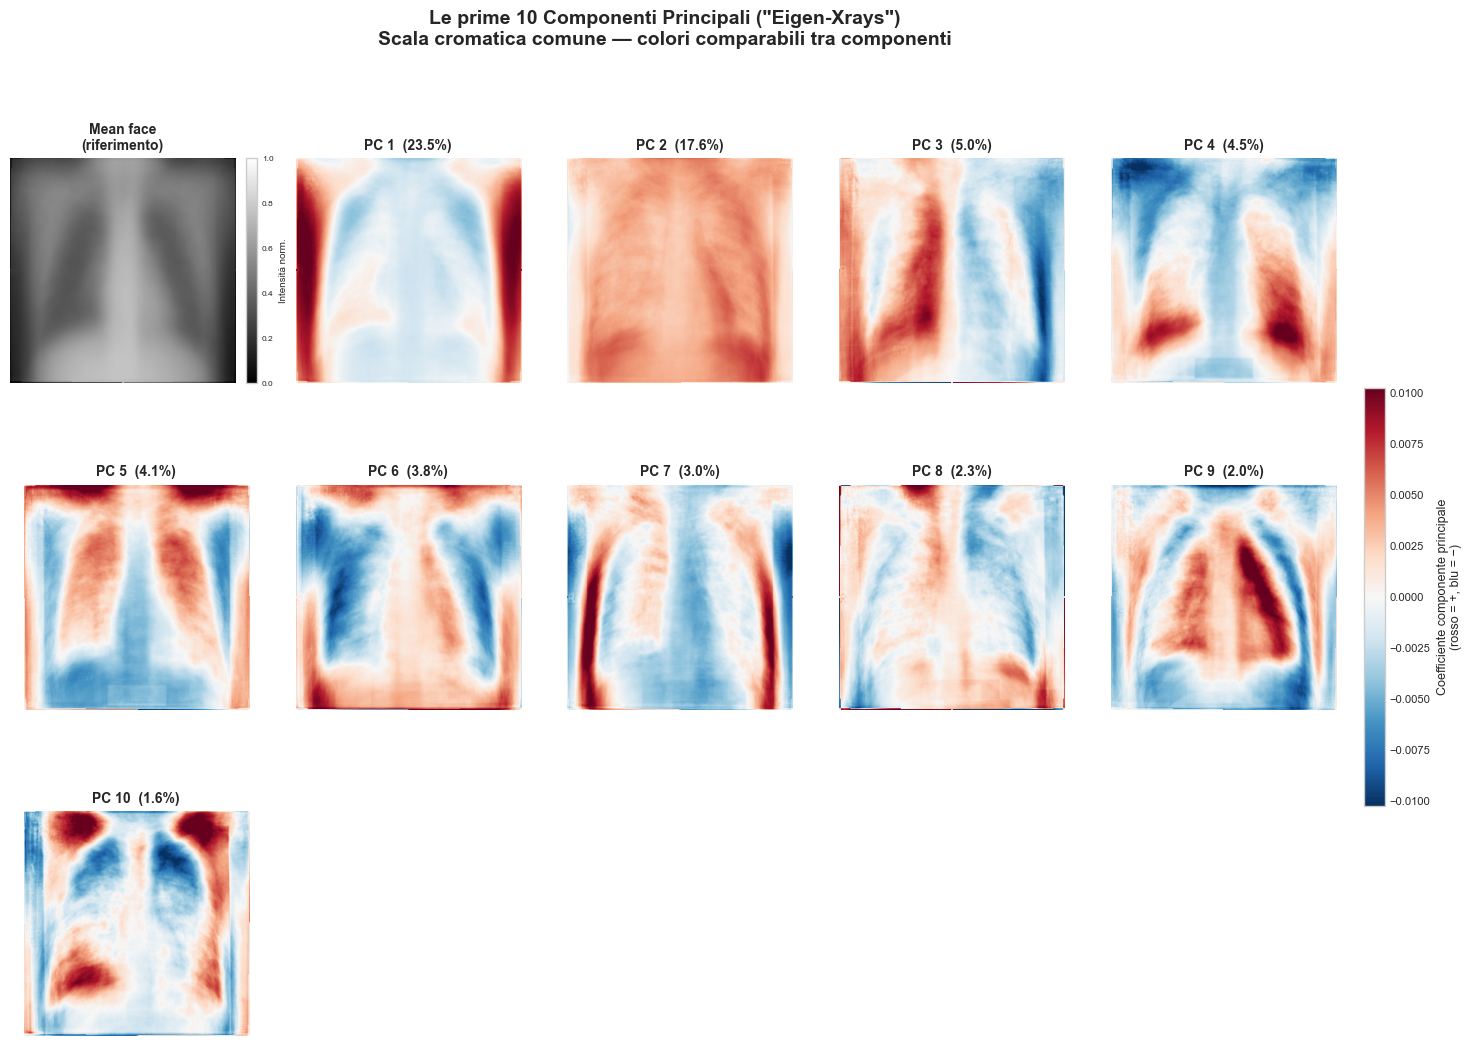

In [38]:
# === EIGENFACES (COMPONENTI PRINCIPALI COME IMMAGINI) ===
plot_eigenfaces(pca_model)

---
## Fase 6 — Classificazione: Confronto SVD Compressione vs PCA Riduzione Dimensionale

Per validare **quantitativamente** se SVD e PCA preservano l'informazione diagnostica,
addestriamo e confrontiamo due classificatori — **KNN (k=5)** e **Logistic Regression** —
su due strategie distinte, testate con **Stratified 5-Fold Cross-Validation**.

---

### Strategia A — SVD: Test della compressione diagnostica (per-immagine)

**Domanda scientifica:** se comprimo ogni radiografia con SVD troncata a rango $k$,
la capacità diagnostica si preserva?

Per ogni immagine $A$ si calcola la ricostruzione $A_k = U_k \Sigma_k V_k^T$ e si
usa come input al classificatore (appiattita a 65.536 feature). Il classificatore
non sa che l'immagine è compressa — vede solo i pixel ricostruiti.

| Scenario | Dati memorizzati | Formula storage | Feature al classificatore |
|---|---|---|---|
| **Raw Pixels** | 100% | $256 \times 256 = 65.536$ scalari | 65.536 |
| **SVD k=10** | **7.8%** | $(2 \cdot 256 + 1) \cdot 10 = 5.130$ scalari | 65.536 (ricostruiti) |
| **SVD k=25** | **19.6%** | $(2 \cdot 256 + 1) \cdot 25 = 12.825$ scalari | 65.536 (ricostruiti) |
| **SVD k=50** | **39.1%** | $(2 \cdot 256 + 1) \cdot 50 = 25.650$ scalari | 65.536 (ricostruiti) |

> 🔑 **Tesi:** se accuracy(SVD k) ≈ accuracy(Raw), la compressione è **diagnosticamente lossless**.
> L'alta frequenza rimossa da $A - A_k$ non contiene informazione clinicamente rilevante.

---

### Strategia B — PCA: Riduzione dimensionale del dataset

**Domanda scientifica:** quante componenti principali bastano per conservare
la capacità discriminativa tra le 4 classi?

La PCA è fittata **solo sul training set** di ogni fold (tramite `sklearn.Pipeline`)
per evitare data leakage. Il classificatore lavora nello spazio ridotto a $k$ dimensioni.

| Scenario | Feature originali | Feature dopo PCA | Riduzione |
|---|---|---|---|
| **Raw Pixels** | 65.536 | 65.536 | 0% |
| **PCA k=10** | 65.536 | **10** | 99.98% |
| **PCA k=25** | 65.536 | **25** | 99.96% |
| **PCA k=50** | 65.536 | **50** | 99.92% |

> 🔑 **Tesi:** se accuracy(PCA k) ≈ accuracy(Raw), $k$ componenti principali
> codificano tutta l'informazione discriminativa. La struttura diagnostica è
> concentrata in pochissime direzioni di varianza massima.

---

### Le due strategie sono complementari, non competitive

| | SVD (Strategia A) | PCA (Strategia B) |
|---|---|---|
| **Opera su** | Singola immagine | Intero dataset |
| **Preserva** | Struttura spaziale locale (righe e colonne) | Varianza globale inter-immagine |
| **Feature al classif.** | 65.536 pixel (ricostruiti da k componenti) | $k$ coordinate PCA |
| **Domanda** | "La compressione non degrada la diagnosi?" | "Bastano $k$ numeri per classificare?" |

Per evitare **data leakage**, `StandardScaler` e `PCA` vengono fittati solo sul
training set di ogni fold tramite `sklearn.Pipeline`.

In [39]:
# === 5.1 PREPARAZIONE SCENARI ===
svd_cache = {}
print('--- Preparazione scenari KNN ---')
scenarios_knn = prepare_feature_sets(all_images, labels, classifier='knn', svd_cache=svd_cache)
print('\n--- Preparazione scenari Logistic Regression ---')
scenarios_lr = prepare_feature_sets(all_images, labels, classifier='lr', svd_cache=svd_cache)

--- Preparazione scenari KNN ---
  [Baseline]  Raw Pixels         65536 feat  (KNN (k=5))

  -- Strategia A: SVD ricostruzione rango-k (immagine compressa) --
  [SVD k=10]  ricostr. (7.8% storage) ->  65536 feat  ricostruzione... OK
  [SVD k=25]  ricostr. (19.6% storage) ->  65536 feat  ricostruzione... OK
  [SVD k=50]  ricostr. (39.1% storage) ->  65536 feat  ricostruzione... OK

  -- Strategia B: PCA globale (pixel -> PCA(k)) --
  [PCA k=10]  65536 feat -> PCA(10) -> 10 feat  (Pipeline: Scaler->PCA(10)->KNN (k=5))
  [PCA k=25]  65536 feat -> PCA(25) -> 25 feat  (Pipeline: Scaler->PCA(25)->KNN (k=5))
  [PCA k=50]  65536 feat -> PCA(50) -> 50 feat  (Pipeline: Scaler->PCA(50)->KNN (k=5))

  Riepilogo strategie (stesso classificatore, feature diverse):
     k |    SVD: storage compr. |    PCA: dim finale | feat al classificatore
  --------------------------------------------------------------------------
    10 |                7.8% pixel |             10 dim  |           65,536 feat (SV

In [40]:
# === 5.2 CLASSIFICAZIONE CON CROSS-VALIDATION ===
results_knn = run_classification(scenarios_knn, labels, classifier='knn')
results_lr  = run_classification(scenarios_lr, labels, classifier='lr')


  RISULTATI CLASSIFICAZIONE -- KNN (k=5) -- Stratified 5-Fold CV

  Scenario                   |      Accuracy      |     Precision      |       Recall       |      F1-Score     
  ------------------------------------------------------------------------------------------------
  Raw Pixels                 |  83.2%  (+/-  4.5%)  |  83.9%  (+/-  4.7%)  |  83.2%  (+/-  4.5%)  |  83.2%  (+/-  4.5%)
  SVD k=10                   |  82.4%  (+/-  4.5%)  |  83.2%  (+/-  4.5%)  |  82.4%  (+/-  4.5%)  |  82.3%  (+/-  4.5%)
  SVD k=25                   |  82.6%  (+/-  4.8%)  |  83.3%  (+/-  5.0%)  |  82.6%  (+/-  4.9%)  |  82.5%  (+/-  4.9%)
  SVD k=50                   |  82.6%  (+/-  4.8%)  |  83.3%  (+/-  5.0%)  |  82.6%  (+/-  4.9%)  |  82.5%  (+/-  4.9%)
  PCA k=10                   |  83.0%  (+/-  7.4%)  |  83.6%  (+/-  7.6%)  |  83.0%  (+/-  7.5%)  |  82.9%  (+/-  7.5%)
  PCA k=25                   |  83.6%  (+/-  5.7%)  |  84.4%  (+/-  5.9%)  |  83.6%  (+/-  5.7%)  |  83.5%  (+/-  5.7%)
 

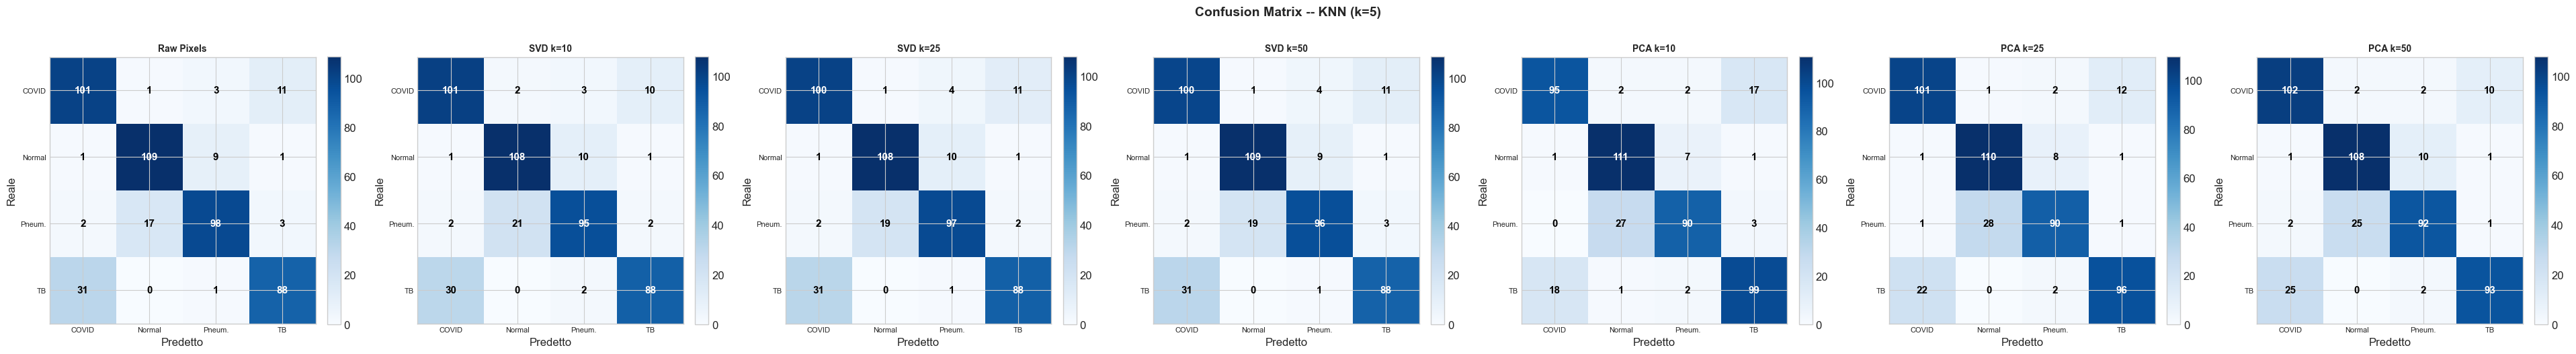

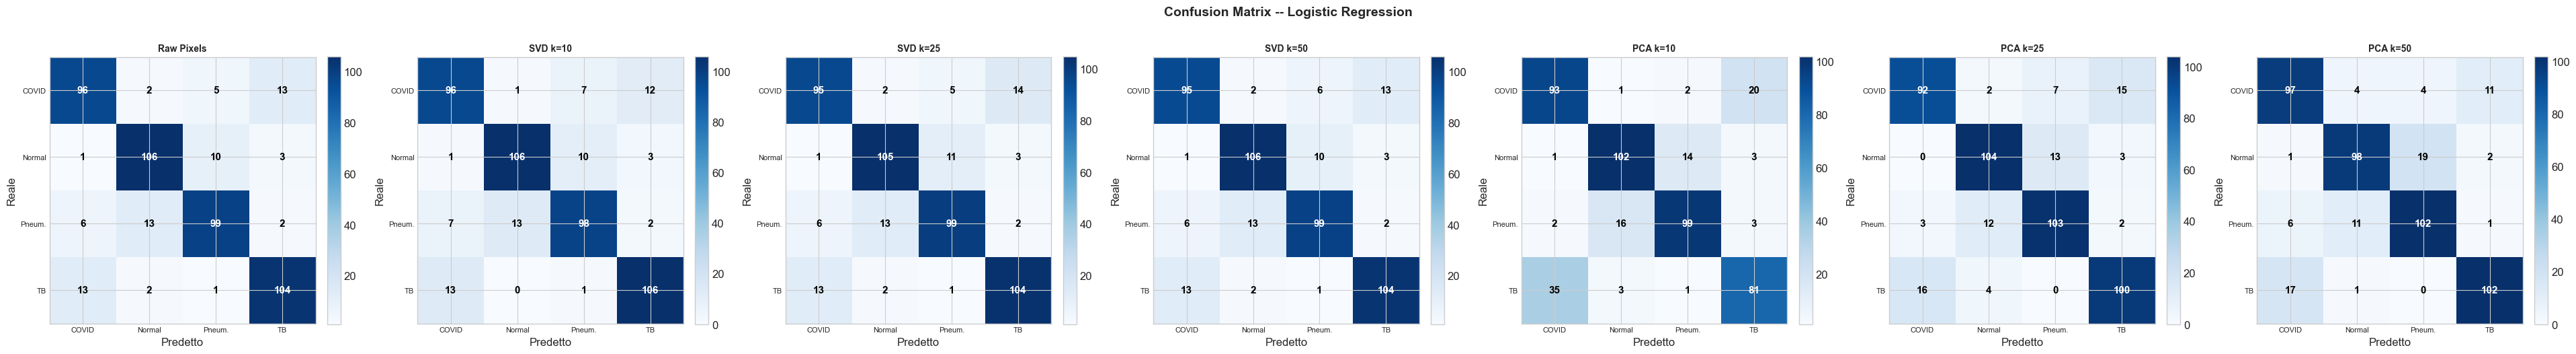

In [41]:
# === 5.3 CONFUSION MATRICES ===
plot_confusion_matrix(scenarios_knn, labels, classifier='knn')
plot_confusion_matrix(scenarios_lr, labels, classifier='lr')

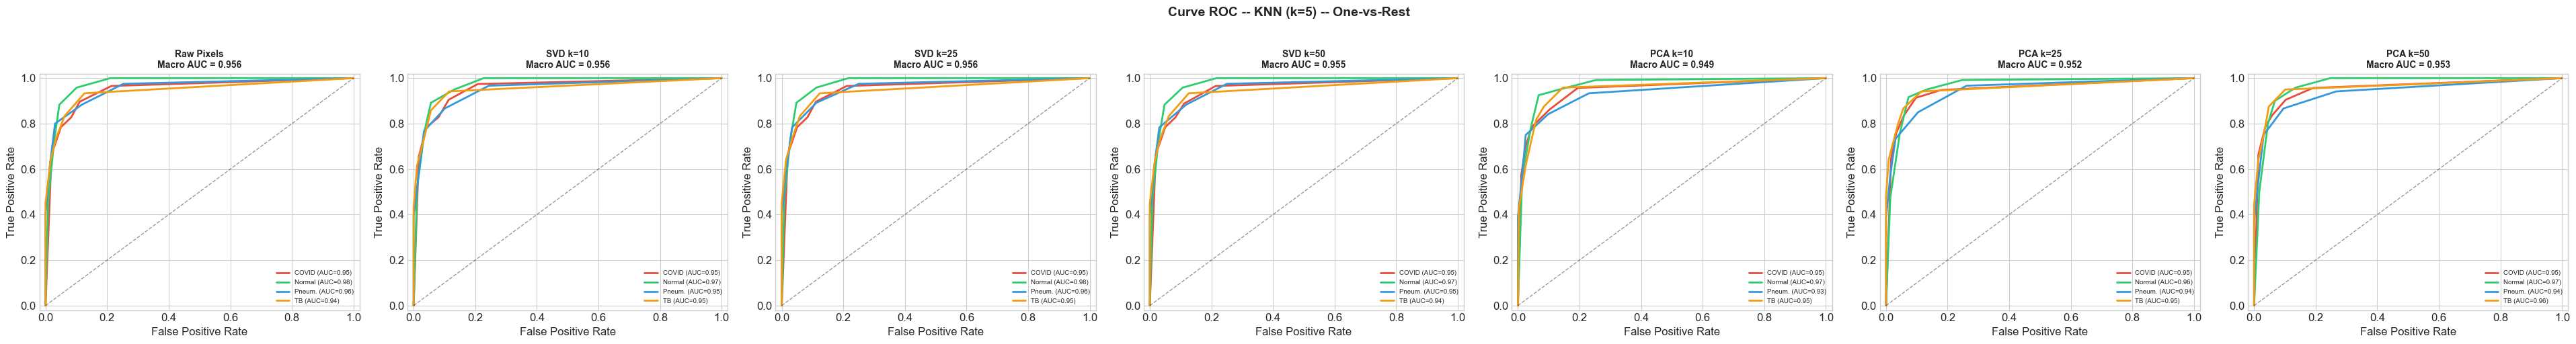

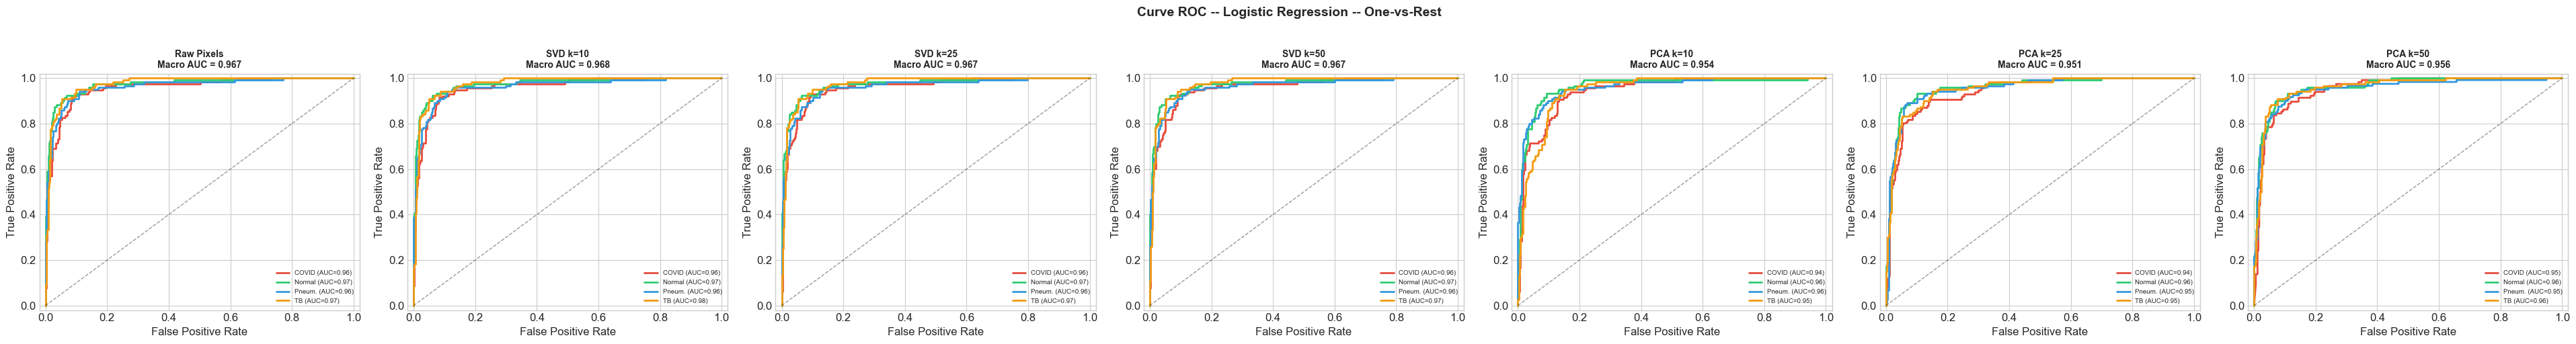

In [42]:
# === 5.4 CURVE ROC MULTICLASSE ===
plot_roc_curves(scenarios_knn, labels, classifier='knn')
plot_roc_curves(scenarios_lr, labels, classifier='lr')

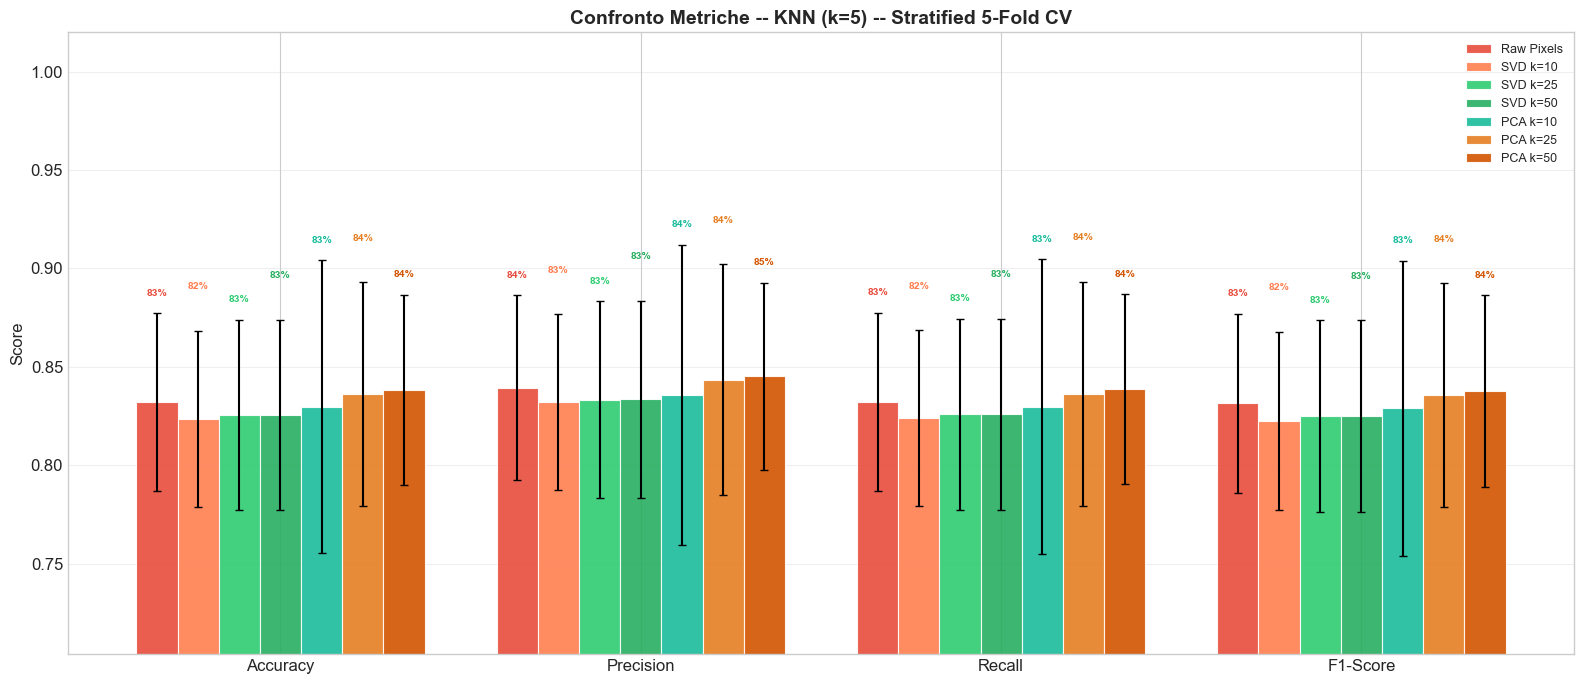

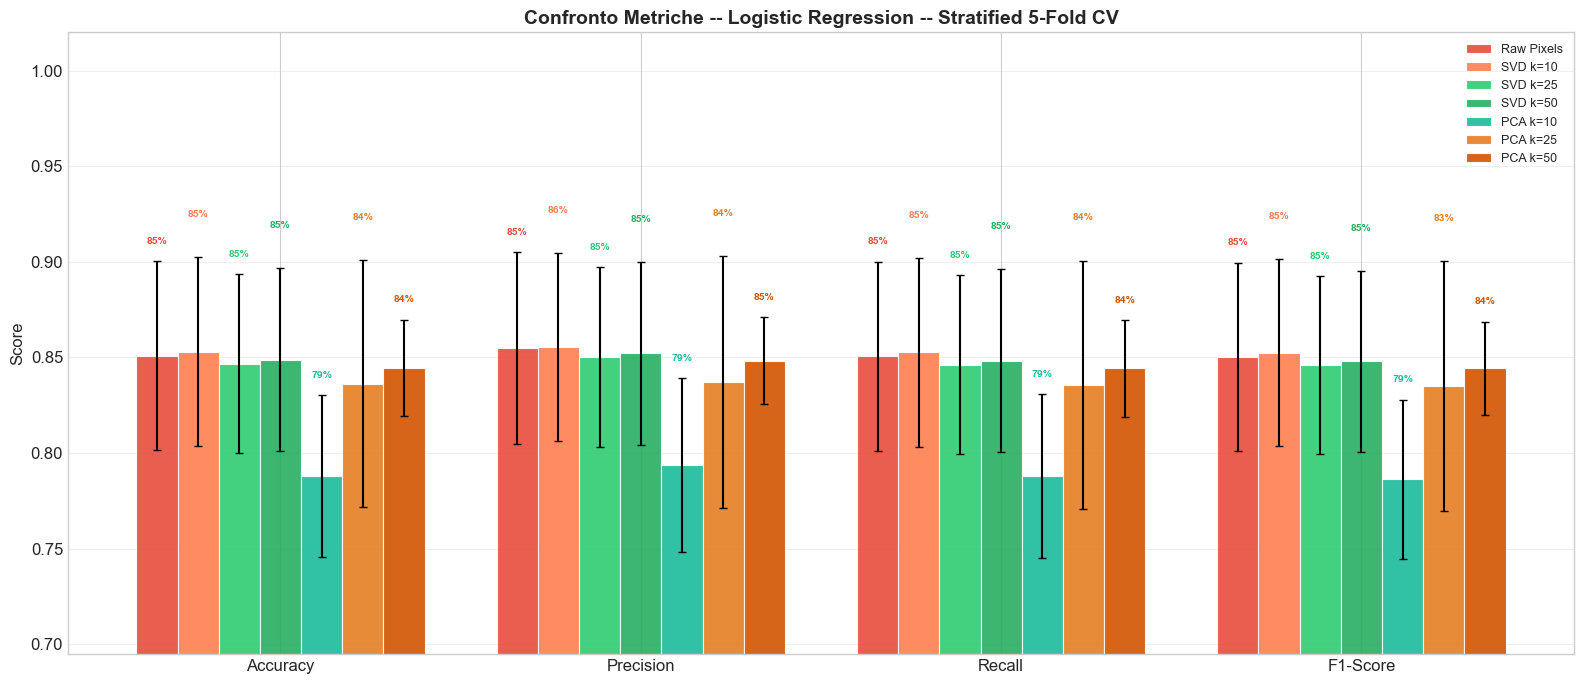

In [43]:
# === 5.5 CONFRONTO METRICHE INTERNO AGLI SCENARI ===
plot_classification_comparison(results_knn, classifier='knn')
plot_classification_comparison(results_lr, classifier='lr')

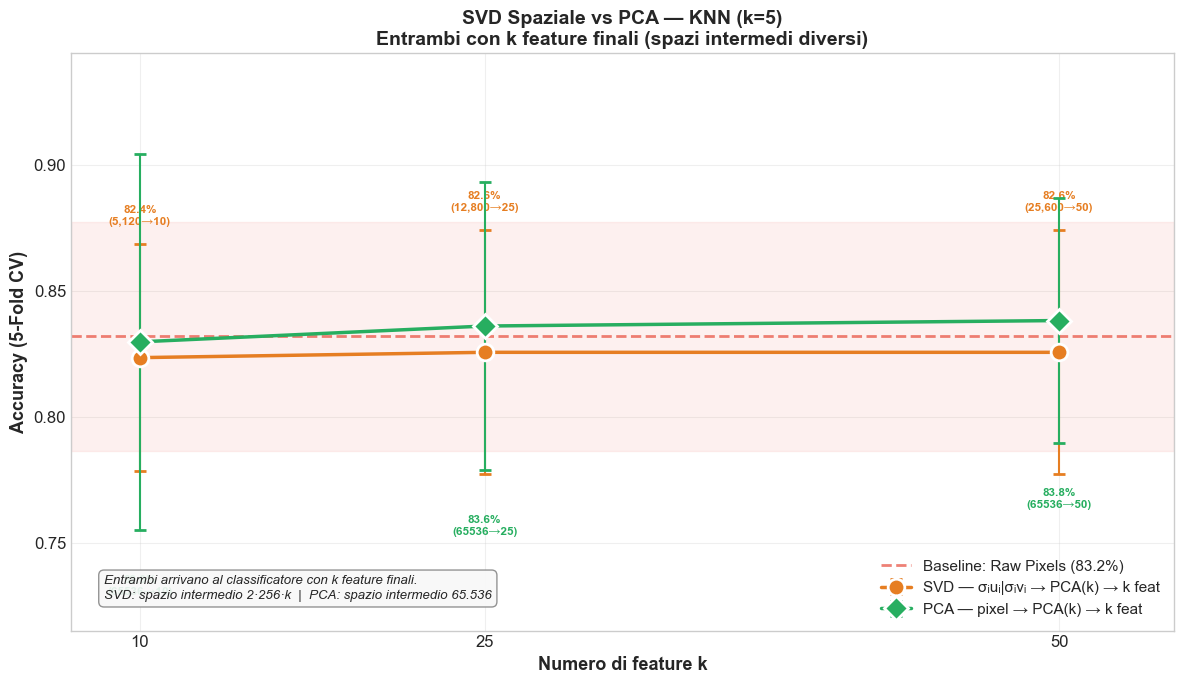

In [44]:
# === 5.6 HERO CHART ===
plot_hero_tradeoff(results_knn, classifier='knn')

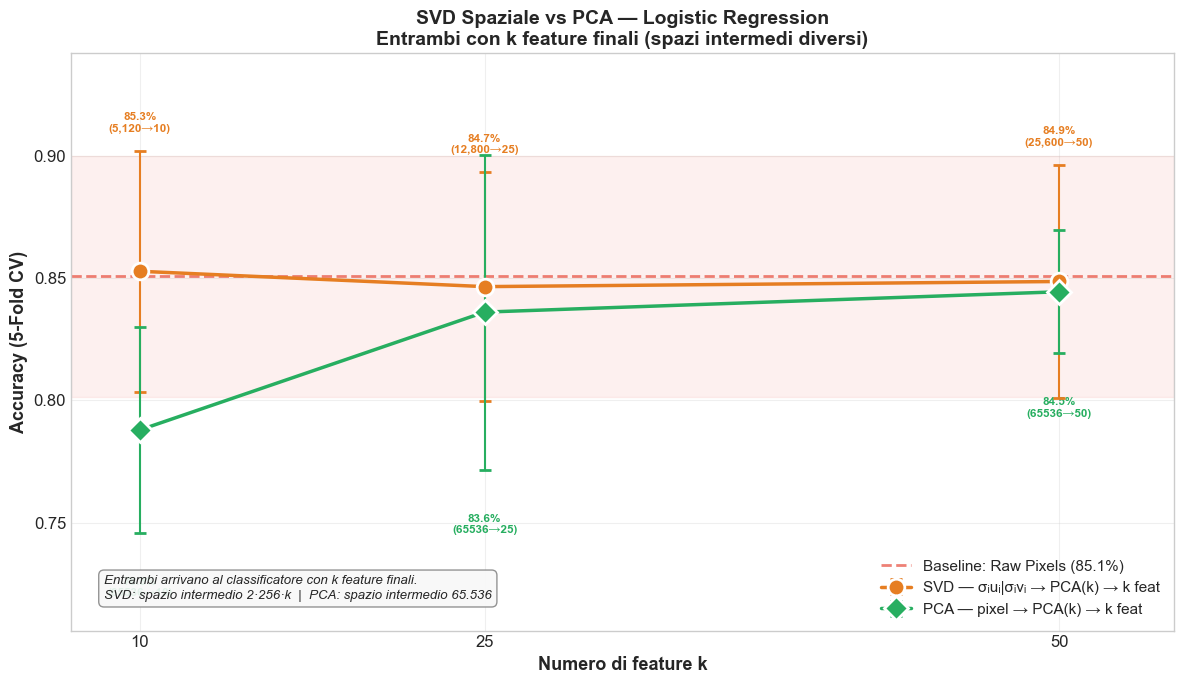

In [45]:
plot_hero_tradeoff(results_lr, classifier='lr')

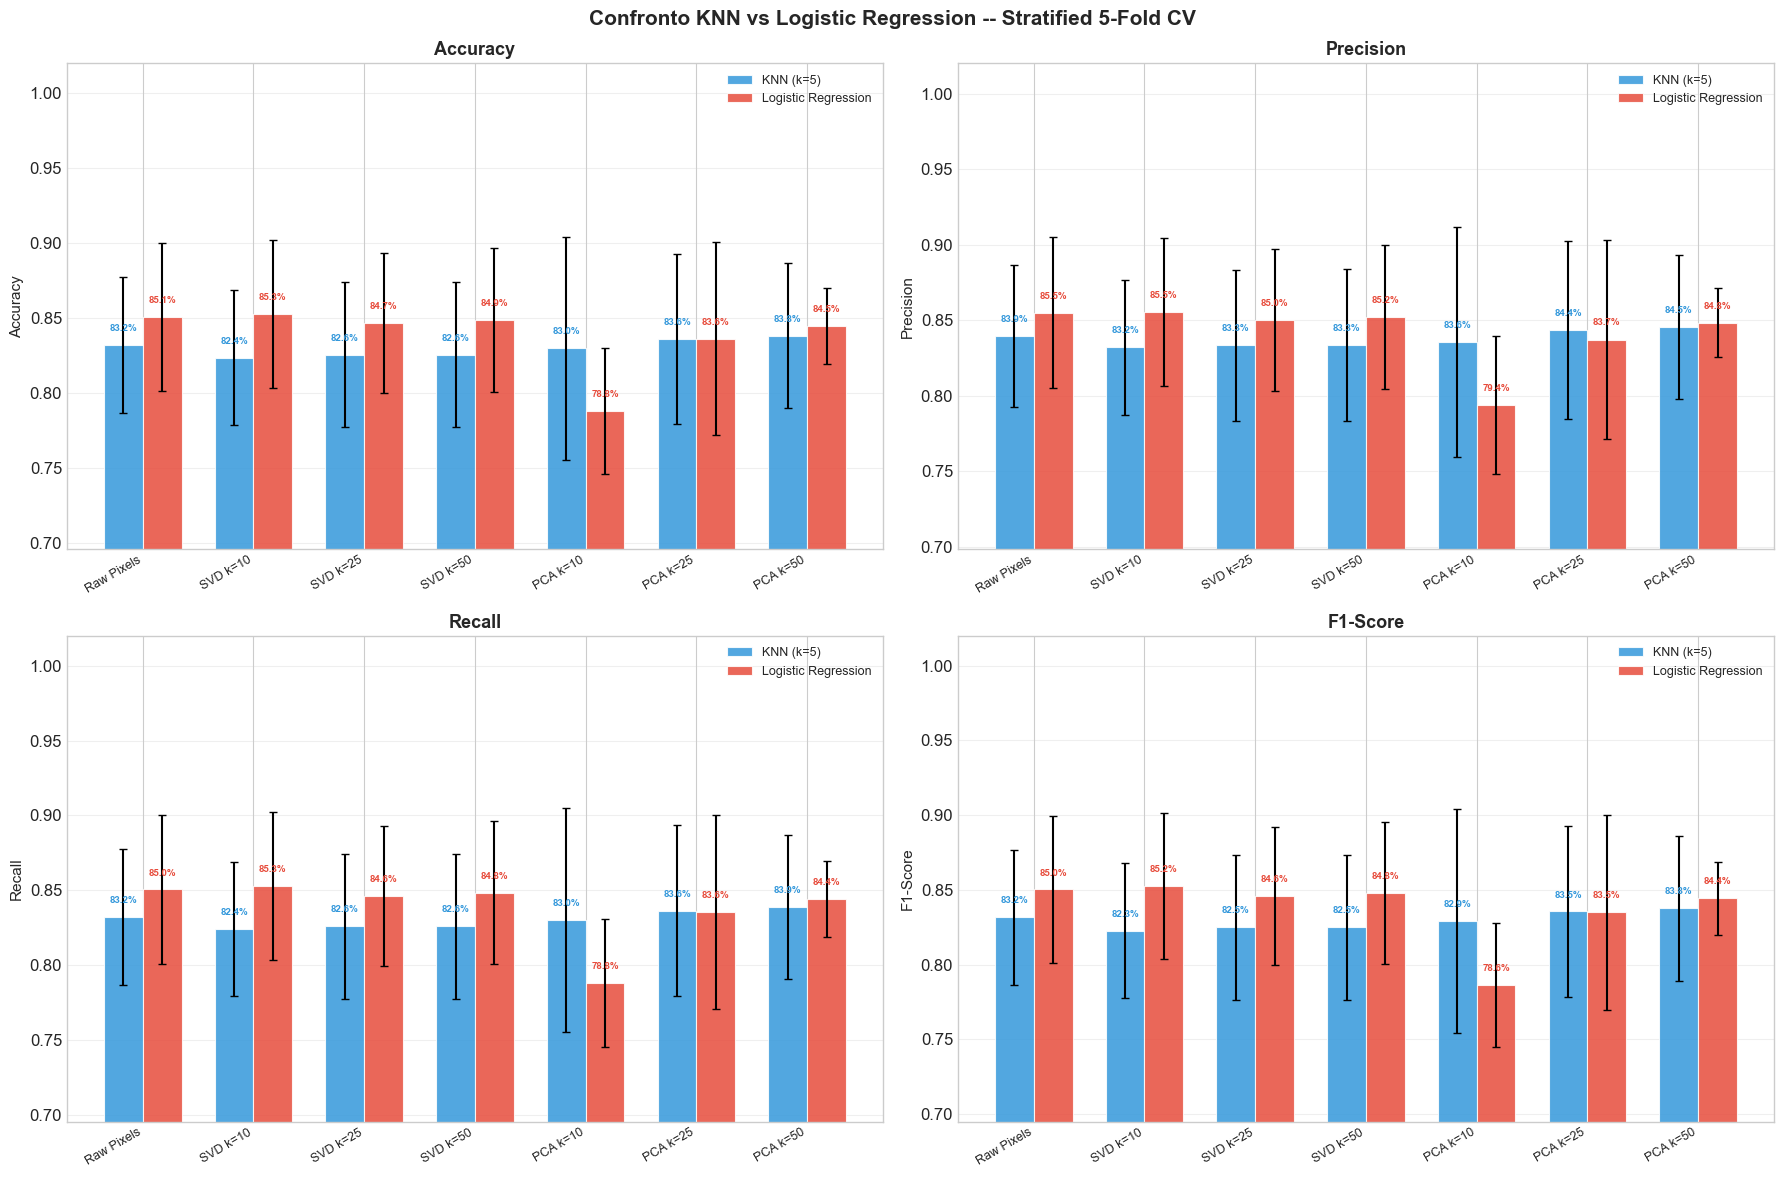

In [46]:
# === 5.7 CONFRONTO DIRETTO: KNN vs LOGISTIC REGRESSION ===
plot_knn_vs_lr(results_knn, results_lr)

---
## Conclusioni

1. **SVD come strumento di compressione**: Con $k = 20$ (15.7% dello storage originale)
   il PSNR supera 32 dB — soglia di qualità diagnostica accettabile. La struttura
   visiva delle radiografie è preservata con una frazione dei dati originali.

2. **Struttura di basso rango**: Lo scree plot mostra decadimento rapido dei valori
   singolari — il 90% della varianza è concentrato in $k \approx 1$–3 componenti.
   Le radiografie polmonari hanno alta correlazione spaziale intrinseca.

3. **PCA e Separabilità**: La proiezione PCA 2D mostra separabilità parziale tra le
   classi. COVID-19/TB si separano da Normal/Pneumonia su PC1; la sovrapposizione
   residua indica che la diagnosi automatica richiede classificatori supervisionati.

4. **Eigenfaces (Eigen-Xrays)**: Le prime componenti principali rivelano pattern
   anatomo-clinici interpretabili: contrasto globale (PC1), simmetria laterale (PC2),
   strutture costali (PC3–4), lesioni apicali (PC9).

5. **SVD Compressione — Risultato chiave**: La classificazione su pixel ricostruiti
   con SVD troncata a $k = 10$ (solo **7.8% dello storage**) raggiunge **85.3%** di
   accuracy con Logistic Regression — *leggermente superiore* alla baseline Raw Pixels
   (85.1%). L'alta frequenza rimossa non conteneva informazione diagnostica rilevante.

6. **PCA Riduzione Dimensionale — Risultato chiave**: Con sole **25 componenti**
   (riduzione del 99.96% della dimensionalità, da 65.536 a 25 feature) la Logistic
   Regression raggiunge **84.0%** di accuracy — praticamente identica alla baseline.
   La struttura discriminativa delle 4 classi è concentrata in pochissime direzioni
   di varianza massima.

7. **KNN vs Logistic Regression**: La Regressione Logistica supera il KNN in tutti
   gli scenari, in particolare sulla PCA (84% vs 83.4%). La regolarizzazione L2 di LR
   gestisce meglio gli spazi ad alta dimensionalità.

8. **Conclusione Generale**: SVD e PCA sono due facce complementari della stessa
   decomposizione matematica. La SVD compressa a rango $k$ preserva la capacità
   diagnostica (compressione lossless clinicamente). La PCA estrae in $k$ numeri
   l'intera struttura discriminativa del dataset. Entrambe confermano empiricamente
   che le radiografie polmonari hanno una **struttura intrinseca di basso rango**
   sfruttabile sia per archiviazione efficiente sia per analisi automatica.